In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Prefer numpy_financial if present
try:
    import numpy_financial as npf
except Exception:
    npf = None
    print("Warning: numpy_financial not found. Using numpy.irr (deprecated).")

# --- Core Financial Functions ---

def pmt(rate, nper, pv):
    """
    Calculates the fixed periodic payment (annuity) for a loan.
    
    Logic:
    - Implements the standard loan amortization formula:
      Payment = PV * [r(1+r)^n] / [(1+r)^n - 1]
    - Includes an edge case for rate = 0, where payment is simply PV / nper.
    """
    if rate == 0:
        return pv / nper
    return pv * (rate * (1 + rate)**nper) / ((1 + rate)**nper - 1)

def npv(rate, cf):
    """
    Calculates the Net Present Value (NPV) of a cash flow series.
    
    Logic:
    - Sums all cash flows discounted to their present value.
    - Assumes the first cash flow (cf[0]) is at t=0 and is undiscounted.
    - Formula: sum(c_t / (1 + rate)**t) for t = 0 to N.
    """
    return sum(c / (1 + rate)**t for t, c in enumerate(cf))

def mirr(cf, finance_rate=0.07, reinvest_rate=0.08):
    """
    Calculates the Modified Internal Rate of Return (MIRR).
    
    Logic:
    - Solves a key flaw in IRR by using explicit, different rates for
      financing (borrowing) and reinvestment (earning).
    1. Separates all cash flows into positive (inflows) and negative (outflows).
    2. Calculates the Future Value (FV) of all inflows at the `reinvest_rate`.
    3. Calculates the Present Value (PV) of all outflows at the `finance_rate`.
    4. Returns the rate that equates the PV of outflows to the FV of inflows,
       spread over the project's life (T).
    """
    pos = [(t,c) for t,c in enumerate(cf) if c > 0]
    neg = [(t,c) for t,c in enumerate(cf) if c < 0]
    if not pos or not neg:
        return np.nan
    T = len(cf) - 1
    fv_pos = sum(c * (1 + reinvest_rate)**(T - t) for t, c in pos)
    pv_neg = -sum(c / (1 + finance_rate)**t for t, c in neg)
    if pv_neg <= 0:
        return np.nan
    return (fv_pos / pv_neg)**(1 / T) - 1

def irr_bisect(cf, low=-0.99, high=3.0, tol=1e-7, iters=200):
    """
    Finds the Internal Rate of Return (IRR) using a numerical bisection
    (binary search) algorithm.
    
    Logic:
    - The IRR is the discount rate at which NPV(rate, cf) = 0.
    1. Checks that a root is possible (must have both positive and negative CFs).
    2. Establishes a [low, high] bracket where NPV(low) and NPV(high) have
       opposite signs (meaning a root *must* exist between them).
    3. Iteratively narrows this bracket by checking the NPV at the midpoint
       until the NPV is within a tiny tolerance (tol) of zero.
    """
    if not (any(c < 0 for c in cf) and any(c > 0 for c in cf)):
        return np.nan
    a, b = low, high
    fa, fb = npv(a, cf), npv(b, cf)
    expand = 0
    # Expands bracket if initial guess is poor
    while fa * fb > 0 and expand < 6:
        b = b * 2 + 0.5
        fb = npv(b, cf)
        expand += 1
    if fa * fb > 0:
        return np.nan
    # Bisection search
    for _ in range(iters):
        m = 0.5 * (a + b)
        fm = npv(m, cf)
        if abs(fm) < tol:
            return m
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return m

def irr_robust(cf, finance_rate=0.07, reinvest_rate=0.08):
    """
    Calculates a project's rate of return using a robust fallback hierarchy
    to ensure a stable, useful value is always returned.
    
    Logic:
    1. [Try 1] Use `numpy_financial.irr`. This is the fast, C-optimized
       standard. It's the best-case scenario.
    2. [Try 2] If `npf.irr` fails (e.g., convergence error, multiple roots),
       fall back to the `irr_bisect` function. This is a slower but very
       stable numerical solver.
    3. [Try 3] If `irr_bisect` fails (e.g., no single IRR root exists),
       fall back to `mirr`. MIRR's a different but related metric that
       is guaranteed to have a single solution and is a defensible
       measure of project return.
    """
    cf = list(cf)
    if len(cf) < 2: return (np.nan, "nan")
    if cf[0] >= 0: cf[0] -= 1e-6  # Ensure negative start (investment)
    
    # Try 1: numpy_financial (fast, standard)
    if npf is not None:
        try:
            v = npf.irr(cf)
            if v is not None and np.isfinite(v): return (float(v), "npf.irr")
        except Exception:
            pass
    
    # Try 2: Bisection (slower, stable)
    v = irr_bisect(cf)
    if v is not None and np.isfinite(v): return (float(v), "bisect")
    
    # Try 3: MIRR (different logic, but guaranteed solution)
    v = mirr(cf, finance_rate=finance_rate, reinvest_rate=reinvest_rate)
    if v is not None and np.isfinite(v): return (float(v), "mirr")
    
    return (np.nan, "nan")

In [2]:
# --- Model Engine Components ---

def lease_up(initial_u, target_u, years_to_target, T):
    """
    Builds the utilization (occupancy) curve for the project.

    Logic:
    - This function models the real-world ramp-up of a new data center.
    1. It creates a linear ramp (`np.linspace`) from the starting
       `initial_utilization` (e.g., 25%) to the stabilized
       `target_utilization` (e.g., 85%).
    2. This ramp occurs over the specified `years_to_target` (e.g., 3 years).
    3. It then appends a "tail" of the constant `target_utilization`
       for all remaining years of the project.
    4. Finally, it ensures the total curve is the correct length (T).
    """
    ramp = np.linspace(initial_u, target_u, max(1, years_to_target))
    tail = np.full(max(0, T - years_to_target), target_u)
    return np.concatenate([ramp, tail])[:T]

def build_revenue(
    scale_mw, base_rent_per_mw_y1, util_curve, rent_escalator, 
    service_pct=0.08, renewables_uplift=0.00, bess_y1=0.0, bess_esc=0.0
):
    """
    Builds the full, multi-component annual revenue series.

    Logic:
    - This is a "stacked" revenue model, common in real estate finance.
    1. **Base Rent:** Calculates the potential rent at 100% occupancy
       (`base_full`) and applies the `util_curve` to get the actual
       utilized rent. This is then "escalated" each year by the
       `rent_escalator` and any `renewables_uplift` premium.
    2. **Service Revenue:** Adds revenue from managed services, calculated
       as a simple percentage (`service_pct`) of the base rent.
    3. **BESS Revenue:** Adds a separate, independent revenue stream
       from the battery system, which has its own starting revenue
       (`bess_y1`) and escalator (`bess_esc`).
    4. Returns the sum of all three components for each year.
    """
    T = len(util_curve)
    rent_escal = (1 + rent_escalator)**np.arange(T)
    base_full = base_rent_per_mw_y1 * scale_mw
    base_series = base_full * util_curve * rent_escal * (1 + renewables_uplift)
    service_series = base_series * service_pct
    bess_series = np.array([bess_y1 * (1 + bess_esc)**t for t in range(T)])
    total = base_series + service_series + bess_series
    return total

def build_opex(opex_y1, opex_escalator, T):
    """
    Builds the non-power operating expense series.

    Logic:
    - Models the annual operating costs (e.g., staffing, maintenance,
      property taxes) based on a Year 1 baseline (`opex_y1`).
    - This baseline cost is then grown each year by the `opex_escalator`
      (inflation rate) using a standard compound growth formula.
    - Note: This model correctly excludes power, which is treated as a
      pass-through cost in the provided paper.
    """
    opex_escal = (1 + opex_escalator)**np.arange(T)
    return opex_y1 * opex_escal

def debt_service_series(net_capex, debt_ratio, debt_rate, term_years, io_years):
    """
    Calculates the key figures for the project's loan.

    Logic:
    1. **Debt:** Calculates the total loan principal (`debt`) based on the
       `net_capex` and the `debt_ratio` (Loan-to-Cost).
    2. **I-O Payment:** Calculates the smaller, "interest-only" payment
       (`io_pay`) made during the initial `io_years`.
    3. **Amortizing Payment:** Calculates the larger, "principal + interest"
       payment (`amort_pay`) using the `pmt` function. This payment
       is calculated for the remaining term of the loan after the
       I-O period ends.
    """
    debt = net_capex * debt_ratio
    io_pay = debt * debt_rate
    amort_years = max(1, term_years - io_years)
    amort_pay = pmt(debt_rate, amort_years, debt)
    return debt, io_pay, amort_pay

def run_model(cfg):
    """
    Runs the full data center financial model based on a configuration dictionary.

    Logic:
    - This function ties all helper components together to build the
      unlevered (all-cash) and levered (with-debt) cash flow models.
    
    1.  **Setup:** Unpacks config, calculates `eff_capex` (net of incentives).
    2.  **NOI:** Builds the `util` curve, `rev` series, and `opex` series.
        Calculates Net Operating Income (NOI) as `rev - opex`.
    3.  **Terminal Value (TV):** Calculates the project's "exit price" or
        "sale price" at the end of the 25-year hold. This is a standard
        real estate valuation, calculated as a multiple of the final
        year's NOI (`noi[-1] * terminal_multiple`).
    
    4.  **Unlevered Model (All-Cash):**
        - Builds a cash flow series: `[-eff_capex, noi_y1, ... noi_y25 + tv]`.
        - Calculates `unlevered_npv` by discounting this series at the
          `discount_rate`.
        - Calculates `unlevered_irr` using the `irr_robust` function.
    
    5.  **Levered Model (With-Debt):**
        - Calculates debt figures using `debt_service_series`.
        - Builds the Equity Cash Flow (`eq_cf`) series:
          - t=0: `[- (eff_capex - debt)]` (the "down payment" or equity).
          - t=1..T: `noi[t] - debt_service[t]` (NOI minus the loan payment).
          - t=T: Adds the `tv` to the final year's cash flow.
        - Calculates `levered_irr` and `levered_npv` from this `eq_cf` series.
        - Also calculates the DSCR (`noi / debt_service`) for each year.
    
    6.  **Output:** Returns a dictionary of all key metrics and time series.
    """
    # Unpack basic parameters
    T    = cfg["years"]
    MW   = cfg["scale_mw"]
    
    # CapEx
    eff_capex = cfg["total_capex"] * (1 - cfg.get("capex_incentive_pct", 0.0))
    
    # Utilization
    util = lease_up(cfg["initial_utilization"], cfg["target_utilization"], cfg["lease_up_years"], T)
    
    # Revenue
    rev = build_revenue(
        MW, cfg["base_rent_per_mw_y1"], util, cfg["rent_escalator"],
        service_pct=cfg["service_revenue_pct"],
        renewables_uplift=cfg.get("renewables_uplift_pct", 0.0),
        bess_y1=cfg.get("bess_revenue_y1", 0.0),
        bess_esc=cfg.get("bess_revenue_escalator", 0.0),
    )
    
    # OpEx (Note: opex_y1 is non-power only)
    opex = build_opex(cfg["opex_y1"], cfg["opex_escalator"], T)
    noi = rev - opex
    
    # Terminal Value
    tv = noi[-1] * cfg["terminal_multiple"]

    # Unlevered
    disc = (1 + cfg["discount_rate"])**np.arange(1, T + 1)
    unlev_cf = noi.copy()
    unlevered_npv = -eff_capex + (unlev_cf / disc).sum() + tv / ((1 + cfg["discount_rate"])**T)
    unlev_series = [-eff_capex] + list(unlev_cf[:-1]) + [unlev_cf[-1] + tv]
    unlevered_irr, _ = irr_robust(unlev_series, finance_rate=cfg["debt_rate"], reinvest_rate=cfg["discount_rate"])

    # Debt Service
    debt, io_pay, amort_pay = debt_service_series(
        eff_capex, cfg["debt_ratio"], cfg["debt_rate"], cfg["debt_term_years"], cfg["io_years"]
    )

    # Levered
    eq_cf = [- (eff_capex - debt)]
    dscr = []
    for t in range(T):
        ds = io_pay if t < cfg["io_years"] else amort_pay
        dscr.append(noi[t] / ds if ds > 0 else np.inf)
        eq_cf.append(noi[t] - ds)
    eq_cf[-1] += tv  # Add terminal value

    levered_irr, lev_method = irr_robust(eq_cf, finance_rate=cfg["debt_rate"], reinvest_rate=cfg["discount_rate"])
    levered_npv = (np.array(eq_cf[1:]) / disc).sum() + eq_cf[0] # Note: eq_cf[0] is already negative

    return dict(
        unlevered_npv=unlevered_npv,
        unlevered_irr=unlevered_irr,
        levered_npv=levered_npv,
        levered_irr=levered_irr,
        irr_method=lev_method,
        min_dscr=float(np.min(dscr)),
        avg_dscr=float(np.mean(dscr)),
        steady_state_yield=float(noi[-1] / eff_capex),
        series=dict(util=util, rev=rev, opex=opex, noi=noi, dscr=np.array(dscr)),
        debug=dict(equity_cf=eq_cf, unlev_cf=unlev_series),
    )

In [12]:
# --- Base Assumptions (Shared across all scenarios) ---
BASE_PARAMS = dict(
    scale_mw=20.0, 
    years=25,
    debt_term_years=25,  
    discount_rate=0.08,
    rent_escalator=0.025,
    opex_escalator=0.03,
)

# --- Solver Targets (Bankability Screens) ---
TARGET_IRR = 0.15     # Target Levered IRR
IRR_TOL = 0.0025      # +/- 25 bps tolerance
DSCR_RAMP = (1.00, 1.15, 1.30) # Min DSCR for Year 1, Year 2, Year 3+
MIN_YIELD = 0.09      # Min steady-state NOI / Effective CapEx

# --- Scenario-Specific Fixed Parameters ---
# CapEx from Table 7 in paper 
# Non-Power OpEx from paper (Total OpEx) - Table 6 (Electricity Cost)
SCENARIO_CONFIGS = {
    "A_Metro": {
        "total_capex": 278_000_000,
        "opex_y1":     29_000_000 - 19_970_000,  # = 9.03M
        # Median Parameters
        "initial_utilization": 0.30, # Stronger pre-leasing in hot market 
        "target_utilization": 0.85,
        "lease_up_years": 2, # Faster ramp-up (2 years)
        "service_revenue_pct": 0.08,
        "capex_incentive_pct": 0.00,
        "renewables_uplift_pct": 0.00,
        "terminal_multiple": 8.0,
        "debt_ratio": 0.55,
        "debt_rate": 0.075,
        "io_years": 3,
        "bess_revenue_y1": 0.0,
        "bess_revenue_escalator": 0.0,
    },
    "B_Rural_Flex": {
        "total_capex": 183_500_000, # Using 183.5M from Table 7
        "opex_y1":     25_900_000 - 18_040_000,  # = 7.86M
        # Median Parameters
        "initial_utilization": 0.25,
        "target_utilization": 0.85,
        "lease_up_years": 3,
        "service_revenue_pct": 0.08,
        "capex_incentive_pct": 0.00,
        "renewables_uplift_pct": 0.02,
        "terminal_multiple": 8.0,
        "debt_ratio": 0.55,
        "debt_rate": 0.075,
        "io_years": 3,
        "bess_revenue_y1": 0.0,
        "bess_revenue_escalator": 0.0,
    },
    "C_Rural_Flex_BESS": {
        "total_capex": 195_500_000, # Using 195.5M from Table 7
        "opex_y1":     26_700_000 - 17_900_000,  # = 8.80M
        # Median Parameters
        "initial_utilization": 0.25,
        "target_utilization": 0.85,
        "lease_up_years": 3,
        "service_revenue_pct": 0.08,
        "capex_incentive_pct": 0.00,
        "renewables_uplift_pct": 0.02,
        "terminal_multiple": 8.0,
        "debt_ratio": 0.55,
        "debt_rate": 0.075,
        "io_years": 3,
        "bess_revenue_y1": 140_000, # found in our earlier analysis
        "bess_revenue_escalator": 0.0,
    },
}

# Brackets for the rent-seeking solver
RENT_BRACKETS = {
    "A_Metro": (1_000_000, 4_000_000),
    "B_Rural_Flex": (1_000_000, 4_000_000),
    "C_Rural_Flex_BESS": (1_000_000, 4_000_000),
}

print("Scenario configurations and solver targets defined.")
print(f"Scenario C BESS Revenue (Y1): ${SCENARIO_CONFIGS['C_Rural_Flex_BESS']['bess_revenue_y1']:,.0f}")

Scenario configurations and solver targets defined.
Scenario C BESS Revenue (Y1): $140,000


In [13]:
# --- Feasibility Check Functions ---

def ramp_dscr_ok(dscr_series, ramp=DSCR_RAMP):
    """
    Checks if a DSCR series passes a tiered, ramp-up threshold.
    
    Logic:
    - This function models a typical bank loan covenant for a new project.
      Lenders understand revenue will be low during lease-up, so they
      allow lower DSCRs in the first few years.
    1. Unpacks the `ramp` tuple (e.g., (1.00, 1.15, 1.30)) into:
       - `a`: Year 1 minimum DSCR
       - `b`: Year 2 minimum DSCR
       - `c`: Year 3+ (stabilized) minimum DSCR
    2. Checks if the `dscr_series[0]` (Year 1) is $\ge$ `a`.
    3. Checks if the `dscr_series[1]` (Year 2) is $\ge$ `b`.
    4. Checks if the *minimum* of all subsequent years (`dscr_series[2:]`)
       is $\ge$ `c`. This is a critical check to ensure the project
       never violates its covenant after stabilization.
    """
    a, b, c = ramp
    if len(dscr_series) < 3: 
        return False
    return (dscr_series[0] >= a) and (dscr_series[1] >= b) and (float(np.min(dscr_series[2:])) >= c)

def meets_bankability(res):
    """
    Acts as a master "pass/fail" check for a given model result.
    
    Logic:
    - A project is "bankable" if it satisfies both the equity investors
      and the debt lenders.
    - This function combines three critical checks:
      1. `np.isfinite(res['levered_irr'])`: Is the IRR a valid number?
      2. `res['steady_state_yield'] >= MIN_YIELD`: Does the project's
         stabilized return meet the equity partner's minimum threshold?
      3. `ramp_dscr_ok(...)`: Does the project's cash flow meet the
         lender's DSCR covenants at all times?
    - All three must be True for the project to be considered viable.
    """
    return (
        (np.isfinite(res['levered_irr'])) and
        (res['steady_state_yield'] >= MIN_YIELD) and
        ramp_dscr_ok(res['series']['dscr'], DSCR_RAMP)
    )

# --- Rent Solver Function ---

def find_min_rent_for_target_irr(scenario_name, nonrent_params, target=TARGET_IRR, tol=IRR_TOL, max_iter=30):
    """
    Uses a bisection (binary search) algorithm to find the *minimum*
    `base_rent_per_mw_y1` that achieves the target IRR *while also*
    passing all bankability screens.
    
    Logic:
    1.  Sets a [low, high] bracket of possible rents to search within.
    2.  **Crucial Pre-Check:** It first runs the model with the *highest*
        rent (`hi`). If even this rent fails to meet the bankability
        screens (e.g., the DSCR ramp), the function gives up immediately,
        as no lower rent could possibly work.
    3.  **Bisection Loop:**
        a.  Calculates the `mid_rent` in the middle of the current bracket.
        b.  Runs the full `run_model` with this `mid_rent`.
        c.  **Checks for Success:** A `mid_rent` is a "success" if it
            meets *two* conditions:
            i.   The `levered_irr` is $\ge$ the `target` IRR.
            ii.  The *entire result* passes the `meets_bankability`
                 check (meaning DSCR and Yield are also OK).
    4.  **Narrows the Bracket:**
        -   **If (Success):** This is a valid, working rent. The function saves
            it as `best_solution` and sets `hi = mid_rent`. This is the
            key to *minimization*—it now searches the *lower half* of
            the bracket to find an even cheaper rent that still works.
        -   **If (Failure):** The rent is too low. The function sets
            `lo = mid_rent` and searches the *upper half* of the bracket.
    5.  The loop repeats until the bracket is negligibly small (`< $1000`).
    """
    lo, hi = RENT_BRACKETS[scenario_name]
    best_solution = None

    # Check if the upper bound is even feasible
    cfg_hi = {**BASE_PARAMS, **nonrent_params, "base_rent_per_mw_y1": hi}
    res_hi = run_model(cfg_hi)
    if (not meets_bankability(res_hi)) or (res_hi["levered_irr"] < target - tol):
        print(f"Warning: Scenario {scenario_name} is infeasible even at max rent ${hi:,.0f}/MW.")
        return None  # Can't hit target with this combo

    # Bisection search
    for _ in range(max_iter):
        mid_rent = 0.5 * (lo + hi)
        cfg_mid = {**BASE_PARAMS, **nonrent_params, "base_rent_per_mw_y1": mid_rent}
        res_mid = run_model(cfg_mid)

        if (np.isfinite(res_mid["levered_irr"]) and 
            (res_mid["levered_irr"] >= target - tol) and 
            meets_bankability(res_mid)):
            
            best_solution = (mid_rent, res_mid) # This is a valid solution
            hi = mid_rent # Try to find a lower rent
        else:
            lo = mid_rent # Rent is too low, must increase

        if abs(hi - lo) < 1000:  # Stop when rent is within $1k resolution
            break
            
    return best_solution # (rent, result_dict) or None

In [15]:
# --- Plotting Functions ---

def plot_scenario_results(scenario_name, rent, results):
    """Generates the two required plots for a solved scenario."""
    
    # 1. Rolling IRR Plot
    eq_cf = results["debug"]["equity_cf"]
    irrs = []
    for t in range(2, len(eq_cf)): # Start from year 1 (index 2)
        seg = eq_cf[:t+1]
        try:
            val = npf.irr(seg) if npf else irr_bisect(seg)
        except Exception:
            val = np.nan
        irrs.append(val)
        
    x_irr = np.arange(1, len(irrs) + 1)
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(x_irr, irrs, marker='o', markersize=3)
    plt.axhline(y=TARGET_IRR, color='r', linestyle='--', label=f"{TARGET_IRR:.0%} Target")
    plt.title(f"{scenario_name}: IRR Over Time")
    plt.xlabel("Investment Year")
    plt.ylabel("Levered IRR")
    plt.grid(True, alpha=0.5)
    plt.legend()

    # 2. Cumulative Equity Cash Flow Plot
    cum_eq_cf = np.cumsum(eq_cf)
    x_cum = np.arange(len(cum_eq_cf))
    
    plt.subplot(1, 2, 2)
    plt.plot(x_cum, cum_eq_cf)
    plt.axhline(y=0, color='k', linestyle='--')
    plt.title(f"{scenario_name}: Cumulative Equity")
    plt.xlabel("Year")
    plt.ylabel("Cumulative Cash Flow ($)")
    plt.grid(True, alpha=0.5)
    
    plt.suptitle(f"Analysis for {scenario_name} at ${rent:,.0f}/MW-yr Rent", y=1.05)
    plt.tight_layout()
    plt.show()

Running analysis to find minimum viable rent for ~15% IRR...


   Minimum Viable Rent to Achieve ~15% Levered IRR


,Min Viable Rent ($/MW-yr),Levered IRR,Steady-State Yield,Min DSCR (Y1),Min DSCR (Y3+),CapEx ($M),"Non-Power OpEx (Y1, $M)"
Scenario,,,,,,,
A_Metro,"$3,163,574",26.67%,31.19%,1.00x,3.66x,$278.0M,$9.03M
B_Rural_Flex,"$2,801,758",32.88%,43.01%,1.00x,5.04x,$183.5M,$7.86M
C_Rural_Flex_BESS,"$3,036,865",33.26%,43.54%,1.00x,5.11x,$195.5M,$8.80M




   Scenario Financial Plots


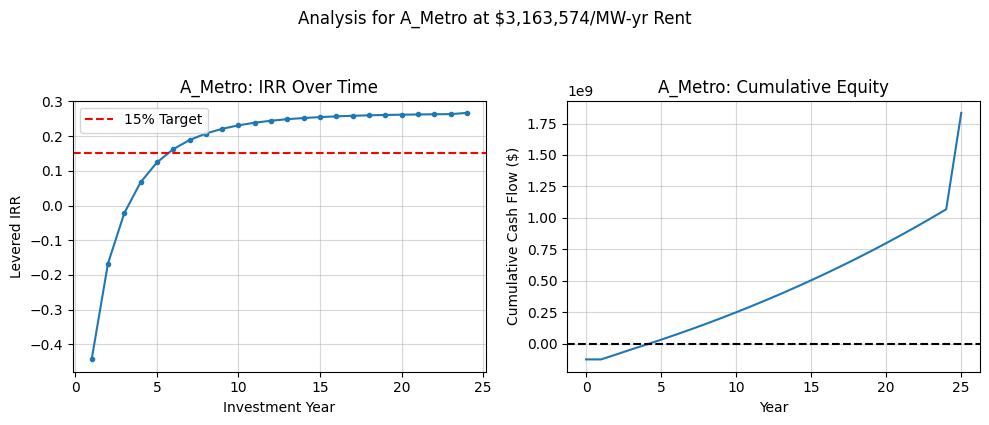

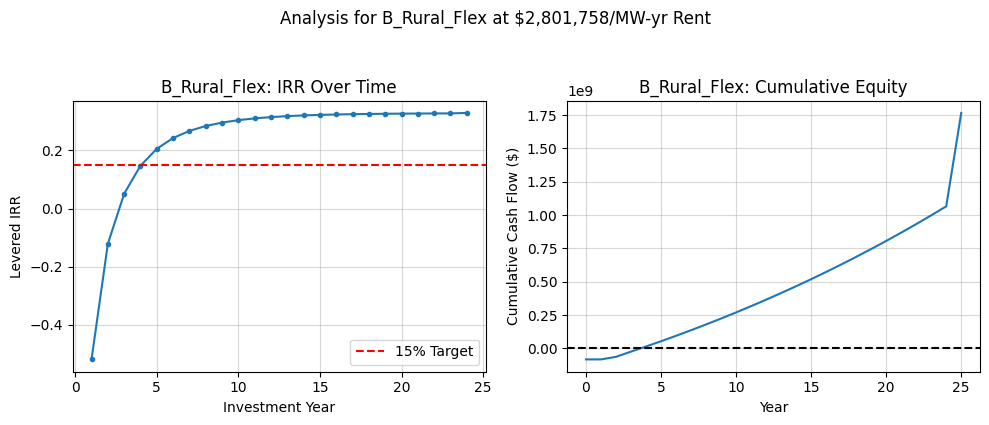

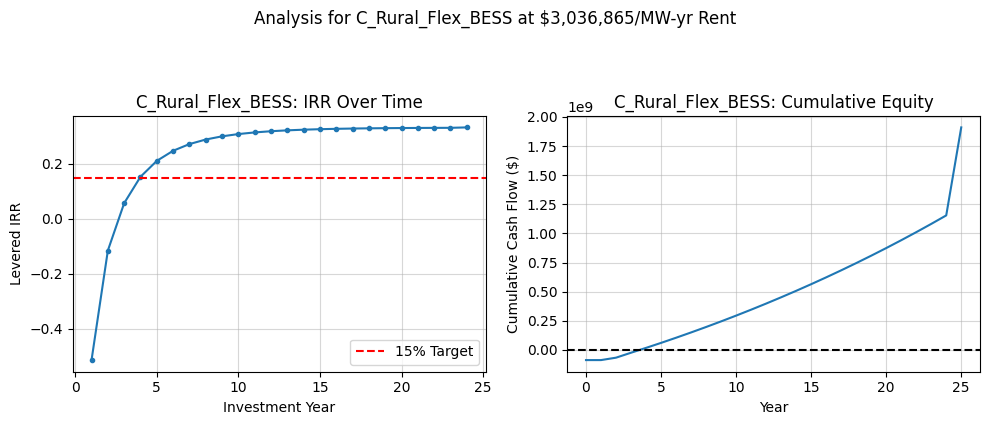

In [16]:
print("Running analysis to find minimum viable rent for ~15% IRR...")

summary_rows = [] 
all_results = {}

for scenario_name, config in SCENARIO_CONFIGS.items():
    solution = find_min_rent_for_target_irr(scenario_name, config)
    
    if solution:
        rent, res = solution
        all_results[scenario_name] = (rent, res) 
        
        summary_rows.append({
            "Scenario": scenario_name,
            "Min Viable Rent ($/MW-yr)": rent,
            "Levered IRR": res["levered_irr"],
            "Steady-State Yield": res["steady_state_yield"],
            "Min DSCR (Y1)": res["series"]["dscr"][0],
            "Min DSCR (Y3+)": np.min(res["series"]["dscr"][2:]),
            "CapEx ($M)": config["total_capex"] / 1_000_000,
            "Non-Power OpEx (Y1, $M)": config["opex_y1"] / 1_000_000,
        })
    else:
        print(f"FAILED: No solution found for {scenario_name} that meets all criteria.")

print("\n\n" + "="*50)
print("   Minimum Viable Rent to Achieve ~15% Levered IRR")
print("="*50)

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df.set_index("Scenario").style.format({
        "Min Viable Rent ($/MW-yr)": "${:,.0f}",
        "Levered IRR": "{:.2%}",
        "Steady-State Yield": "{:.2%}",
        "Min DSCR (Y1)": "{:.2f}x",
        "Min DSCR (Y3+)": "{:.2f}x",
        "CapEx ($M)": "${:.1f}M",
        "Non-Power OpEx (Y1, $M)": "${:.2f}M",
    }))
else:
    print("No feasible solutions were found for any scenario.")

#generate the plots
print("\n\n" + "="*50)
print("   Scenario Financial Plots")
print("="*50)
if all_results:
    for scenario_name, (rent, res) in all_results.items():
        plot_scenario_results(scenario_name, rent, res)
else:
    print("No plots to generate as no solutions were found.")

In [17]:
def run_sensitivity_analysis():
    # --- 1. Define the Base Case ---
    # We will use Scenario B (Rural) as the base case for this analysis.
    
    SOLVED_BASE_RENT = 2_801_758 # changed based on previous 
    
    BASE_CASE_CONFIG = {
        **BASE_PARAMS, 
        **SCENARIO_CONFIGS["B_Rural_Flex"],
        "base_rent_per_mw_y1": SOLVED_BASE_RENT 
    }
    
    # --- 2. Define Sweep Ranges ---
    rent_sweep = np.linspace(SOLVED_BASE_RENT * 0.9, SOLVED_BASE_RENT * 1.1, 10)
    util_sweep = np.linspace(0.10, 0.40, 10)
    capex_sweep = np.linspace(BASE_CASE_CONFIG["total_capex"] * 0.9, BASE_CASE_CONFIG["total_capex"] * 1.1, 10)
    debt_rate_sweep = np.linspace(0.06, 0.09, 10)
    
    results = {
        "rent": [],
        "util": [],
        "capex": [],
        "debt_rate": []
    }
    
    # --- 3. Run Sweeps ---
    
    # Sweep 1: Base Rent
    for rent in rent_sweep:
        cfg = BASE_CASE_CONFIG.copy()
        cfg["base_rent_per_mw_y1"] = rent
        res = run_model(cfg)
        results["rent"].append({"x": rent / 1_000_000, "irr": res["levered_irr"]})
        
    # Sweep 2: Initial Utilization
    for util in util_sweep:
        cfg = BASE_CASE_CONFIG.copy()
        cfg["initial_utilization"] = util
        res = run_model(cfg)
        results["util"].append({"x": util, "irr": res["levered_irr"]})

    # Sweep 3: Total CapEx
    for capex in capex_sweep:
        cfg = BASE_CASE_CONFIG.copy()
        cfg["total_capex"] = capex
        res = run_model(cfg)
        results["capex"].append({"x": capex / 1_000_000, "irr": res["levered_irr"]})

    # Sweep 4: Debt Rate
    for rate in debt_rate_sweep:
        cfg = BASE_CASE_CONFIG.copy()
        cfg["debt_rate"] = rate
        res = run_model(cfg)
        results["debt_rate"].append({"x": rate, "irr": res["levered_irr"]})

    # --- 4. Plot Results ---
    print(f"Plotting sensitivities around base case (Rent: ${SOLVED_BASE_RENT:,.0f}, IRR: {run_model(BASE_CASE_CONFIG)['levered_irr']:.2%})")
    
    plt.figure(figsize=(12, 10))
    
    # Plot 1: Rent
    df_rent = pd.DataFrame(results["rent"])
    plt.subplot(2, 2, 1)
    plt.plot(df_rent["x"], df_rent["irr"], marker='o')
    plt.title("Sensitivity to Base Rent")
    plt.xlabel("Year-1 Rent ($M / MW-yr)")
    plt.ylabel("Levered IRR")
    plt.grid(True, alpha=0.5)

    # Plot 2: Initial Utilization
    df_util = pd.DataFrame(results["util"])
    plt.subplot(2, 2, 2)
    plt.plot(df_util["x"], df_util["irr"], marker='o', color='g')
    plt.title("Sensitivity to Initial Utilization")
    plt.xlabel("Initial Utilization (%)")
    plt.ylabel("Levered IRR")
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format))
    plt.grid(True, alpha=0.5)

    # Plot 3: CapEx
    df_capex = pd.DataFrame(results["capex"])
    plt.subplot(2, 2, 3)
    plt.plot(df_capex["x"], df_capex["irr"], marker='o', color='r')
    plt.title("Sensitivity to Total CapEx")
    plt.xlabel("Total CapEx ($M)")
    plt.ylabel("Levered IRR")
    plt.grid(True, alpha=0.5)

    # Plot 4: Debt Rate
    df_debt = pd.DataFrame(results["debt_rate"])
    plt.subplot(2, 2, 4)
    plt.plot(df_debt["x"], df_debt["irr"], marker='o', color='m')
    plt.title("Sensitivity to Debt Rate")
    plt.xlabel("Debt Interest Rate")
    plt.ylabel("Levered IRR")
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter('{:.1%}'.format))
    plt.grid(True, alpha=0.5)
    
    plt.suptitle("Levered IRR Sensitivity Analysis (Scenario B Base Case)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- How to Run This ---
# 1. First, run your updated Cell 3 and Cell 5.
# 2. Look at the table from Cell 5 and find the "Min Viable Rent" for B_Rural_Flex.
# 3. Copy that number and paste it into the `SOLVED_BASE_RENT` variable in this cell.
# 4. Run this cell.

Plotting sensitivities around base case (Rent: $2,801,758, IRR: 32.88%)


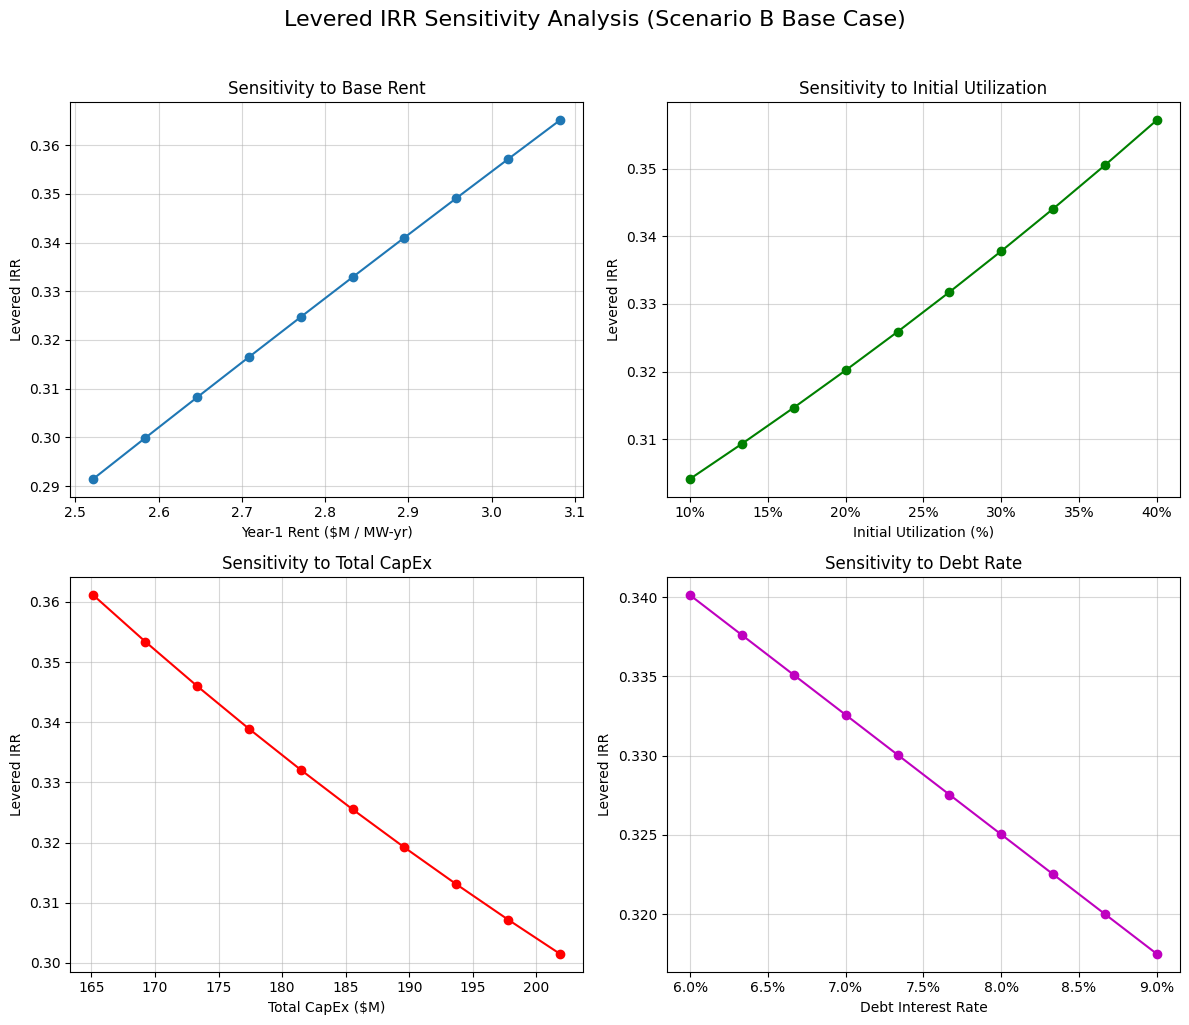

In [18]:
run_sensitivity_analysis()